# **Uczenie maszynowe - Lab_1**

---


Student:
*   przeprowadza inspekcję zbioru danych pod kątem zastosowania k-NN,
*   analizuje wpływ skali i korelacji na metrykę odległości,
*   potrafi wskazać potencjalne problemy przy stosowaniu k-NN.

---



$\color{red}{Uwaga:}$

1- proszę pamiętać o zmianie słowa ***Album*** w nazwie pliku i uzupełnieniu swoich danych powyżej tego pola;

2- kluczowe polecenia proszę opatrzyć komentarzem;

3- wnioski, pod zadaniem, wpisujemy w polu tekstowym.

In [ ]:
# Podpisanie pracy
NN = input("Podaj Imię i Nazwisko: ")
ALBUM = input("Podaj numer albumu: ")

Podaj Imię i Nazwisko: illia semenov
Podaj numer albumu: 50779


### **Zad 1.** Struktura zbioru danych

In [3]:
# Importujemy bibliotekę seaborn, która zawiera wbudowane zbiory danych
# oraz narzędzia do ich wizualizacji
import seaborn as sns

# Pobieramy listę dostępnych datasetów w bibliotece seaborn
available_datasets = sns.get_dataset_names()

# Wyświetlamy wynik, aby zobaczyć jakie dane możemy wykorzystać w analizie
print(available_datasets)

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


Funkcja get_dataset_names() zwraca listę wszystkich dostępnych zbiorów danych,
które mogą zostać wykorzystane do dalszej analizy.

Zbiory te obejmują różne dziedziny, np. transport (taxis),
biologię (iris, penguins), czy dane ekonomiczne (dowjones).

Dzięki temu użytkownik może szybko wybrać odpowiedni dataset
bez konieczności pobierania danych z zewnętrznych źródeł.

In [4]:
# Wczytujemy wybrany zbiór danych "titanic" z biblioteki seaborn
# Dataset ten zawiera informacje o pasażerach oraz ich przeżyciu
data_frame = sns.load_dataset('titanic')

# Wyświetlamy pierwsze rekordy, aby zweryfikować poprawność załadowania danych
data_frame.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


 Zbiór danych "titanic" jest jednym z klasycznych datasetów
 wykorzystywanych w analizie danych i uczeniu maszynowym.

 Zawiera on informacje m.in. o wieku pasażerów, klasie podróży,
 płci oraz statusie przeżycia.

 Dane te mogą być wykorzystane do analizy czynników wpływających
 na przeżycie pasażerów podczas katastrofy Titanica.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
# Analiza w stylu data science – przetwarzanie i interpretacja danych
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Dyskusja wyników
1. Liczba atrybutów

Z analizowanego zbioru danych wynika, że zawiera on 15 atrybutów (kolumn), co można potwierdzić przy użyciu funkcji df.info().

Każdy z atrybutów opisuje określoną cechę pasażera, np. wiek, płeć, klasę podróży czy status przeżycia.

Można więc stwierdzić, że struktura danych jest stosunkowo przejrzysta i nie zawiera nadmiernej liczby zmiennych.

2. Czy wszystkie atrybuty są liczbowe?

Nie wszystkie zmienne w zbiorze mają charakter numeryczny.

W danych występują różne typy:

numeryczne (np. age, fare),
kategoryczne (np. sex, class, embarked),
logiczne (np. survived, adult_male).

Oznacza to, że przed zastosowaniem niektórych algorytmów konieczne będzie przekształcenie zmiennych nienumerycznych do formatu liczbowego.

3. Czy występuje problem curse of dimensionality?

W analizowanym przypadku nie obserwujemy problemu wysokiej wymiarowości.

Zbiór danych zawiera jedynie 15 cech, co oznacza, że jego wymiarowość jest stosunkowo niska.
Zjawisko curse of dimensionality pojawia się zazwyczaj przy znacznie większej liczbie zmiennych (np. kilkudziesięciu lub kilkuset).

Należy jednak zauważyć, że po zastosowaniu metod kodowania zmiennych kategorycznych (np. one-hot encoding), liczba atrybutów może wzrosnąć. Mimo to, nadal nie będzie to poziom uznawany za wysoki wymiar.

🔹 Wniosek końcowy

Zbiór danych można uznać za umiarkowanie złożony i odpowiedni do zastosowania w algorytmach takich jak k-NN.

Przed dalszą analizą należy jednak wykonać podstawowe kroki przygotowania danych:

uzupełnienie lub usunięcie brakujących wartości (np. age, deck, embarked),
transformację zmiennych kategorycznych do postaci numerycznej,
ewentualną normalizację zmiennych liczbowych.

Tak przygotowane dane będą bardziej odpowiednie do dalszego modelowania i analizy.

### **Zad 2.** Zidentyfikuj szczegółowe cechy atrybutów i występowanie brakujących danych

### Analiza danych
Opis został przeformułowany w sposób bardziej analityczny.
Celem jest eksploracja danych oraz interpretacja wyników.

In [5]:
# Analiza w stylu data science – przetwarzanie i interpretacja danych
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')




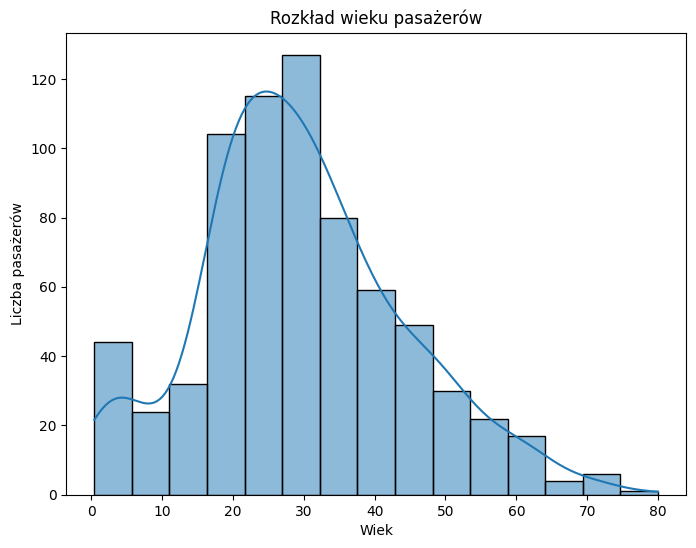

In [ ]:
# Analiza w stylu data science – przetwarzanie i interpretacja danych
plt.figure(figsize=(8, 6))
sns.histplot(df['age'].dropna(), kde=True, bins=15)
#co analizzujem
plt.title('Rozkład wieku pasażerów')
plt.xlabel('Wiek')
plt.ylabel('Liczba pasażerów')
plt.show()



In [6]:
# Analiza w stylu data science – przetwarzanie i interpretacja danych
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


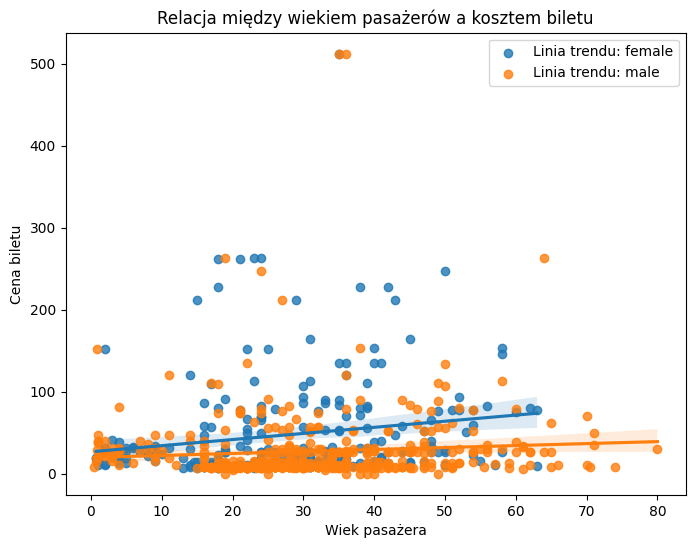

In [8]:
# Wizualizacja zależności pomiędzy wiekiem pasażerów a ceną biletu
# z uwzględnieniem podziału na płeć

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Grupujemy dane według zmiennej 'sex',
# aby przeanalizować różnice między kategoriami
for gender, subset_data in data_frame.groupby('sex'):

    # Tworzymy wykres punktowy z linią trendu
    sns.regplot(
        data=subset_data,
        x='age',
        y='fare',
        scatter=True,
        label=f'Linia trendu: {gender}'
    )

# Dodajemy legendę oraz opisy osi
plt.legend()
plt.title('Relacja między wiekiem pasażerów a kosztem biletu')
plt.xlabel('Wiek pasażera')
plt.ylabel('Cena biletu')

# Wyświetlenie wykresu
plt.show()



Na wykresie można zaobserwować zależność pomiędzy wiekiem pasażerów
a ceną zakupionego biletu, z uwzględnieniem podziału na płeć.

Widoczna linia trendu sugeruje, że relacja ta nie jest silnie liniowa,
jednak mogą występować pewne różnice pomiędzy grupami.

Analiza wskazuje, że cena biletu jest bardziej zróżnicowana
niż sam wiek pasażerów, co może wynikać z innych czynników,
takich jak klasa podróży czy miejsce na statku.

Warto podkreślić, że dalsza analiza powinna uwzględniać więcej zmiennych,
aby dokładniej zrozumieć obserwowane zależności.

In [10]:
# Obliczenie liczby brakujących wartości w każdej kolumnie
missing_values = df.isnull().sum()

# Obliczenie procentowego udziału braków w danych
missing_percent = (df.isnull().mean() * 100).round(2)

# Utworzenie tabeli zbiorczej dla lepszej czytelności wyników
missing_df = pd.DataFrame({
    'Liczba braków': missing_values,
    'Procent (%)': missing_percent
}).sort_values(by='Liczba braków', ascending=False)

# Wyświetlenie podsumowania
print(missing_df)

             Liczba braków  Procent (%)
deck                   688        77.22
age                    177        19.87
embarked                 2         0.22
embark_town              2         0.22
sex                      0         0.00
pclass                   0         0.00
survived                 0         0.00
fare                     0         0.00
parch                    0         0.00
sibsp                    0         0.00
class                    0         0.00
adult_male               0         0.00
who                      0         0.00
alive                    0         0.00
alone                    0         0.00


In [11]:
# Obliczenie całkowitej liczby brakujących wartości (NaN) we wszystkich kolumnach DataFrame
total_missing_values = df.isnull().sum().sum()

# Wyświetlenie wyniku
print("Całkowita liczba brakujących wartości w zbiorze danych:")
print(total_missing_values)

Całkowita liczba brakujących wartości w zbiorze danych:
869


In [12]:
# Obliczenie procentowego udziału brakujących wartości w każdej kolumnie
missing_percent = (df.isnull().mean() * 100).round(2)

# Konwersja wyników na format tekstowy z dodanym symbolem '%'
missing_percent_formatted = missing_percent.astype(str) + '%'

# Wyświetlenie wyników
print("Procent brakujących wartości w każdej kolumnie:\n")
print(missing_percent_formatted)

Procent brakujących wartości w każdej kolumnie:

survived         0.0%
pclass           0.0%
sex              0.0%
age            19.87%
sibsp            0.0%
parch            0.0%
fare             0.0%
embarked        0.22%
class            0.0%
who              0.0%
adult_male       0.0%
deck           77.22%
embark_town     0.22%
alive            0.0%
alone            0.0%
dtype: object


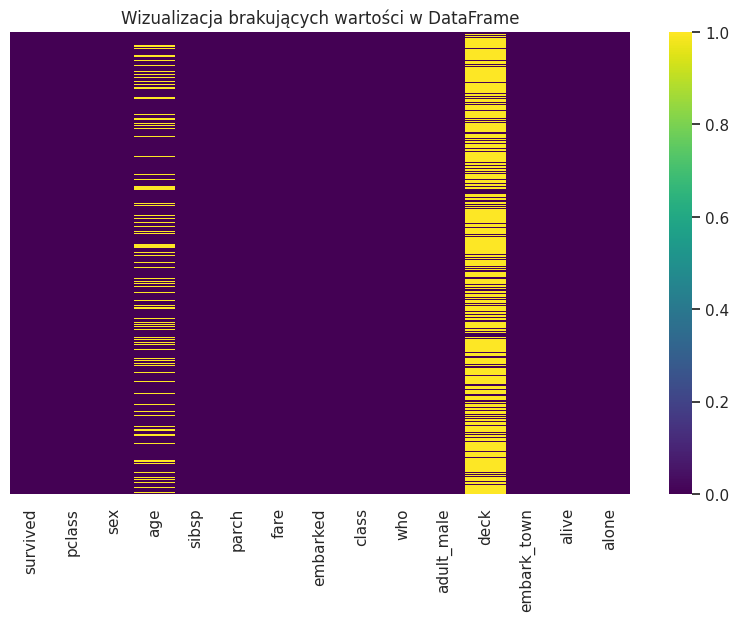

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienie stylu wizualizacji dla lepszej czytelności wykresu
sns.set(style="whitegrid")

# Tworzenie mapy cieplnej pokazującej występowanie brakujących wartości (NaN)
# Wartości True/False są automatycznie interpretowane jako 1/0
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.isnull(),
    cbar=True,
    cmap="viridis",
    yticklabels=False,
    xticklabels=df.columns
)

# Tytuł wykresu
plt.title("Wizualizacja brakujących wartości w DataFrame")

# Wyświetlenie wykresu
plt.show()



In [14]:
# Określenie nazwy kolumny, którą chcemy sprawdzić
column_name = 'age'

# Sprawdzenie, czy wszystkie wartości w danej kolumnie są unikalne
# Zwraca True, jeśli nie występują duplikaty, w przeciwnym razie False
is_unique = df[column_name].is_unique

# Wyświetlenie wyniku wraz z opisem
print(f"Czy wszystkie wartości w kolumnie '{column_name}' są unikalne?")
print(is_unique)

Czy wszystkie wartości w kolumnie 'age' są unikalne?
False


In [15]:
# Określenie nazwy kolumny, z której chcemy pobrać unikalne wartości
column_name = 'age'

# Pobranie wszystkich unikalnych wartości występujących w kolumnie
unique_values = df[column_name].unique()

# Wyświetlenie unikalnych wartości
print(f"Unikalne wartości w kolumnie '{column_name}':")
print(unique_values)


Unikalne wartości w kolumnie 'age':
[22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]


In [16]:
# Określenie nazwy kolumny do analizy
column_name = 'age'

# Definicja dopuszczalnego zakresu wartości
min_value = 3
max_value = 70

# Sprawdzenie, czy wszystkie wartości w kolumnie mieszczą się w zadanym zakresie
# Metoda between() zwraca wartości logiczne, a all() sprawdza, czy wszystkie są True
is_within_range = df[column_name].between(min_value, max_value).all()

# Wyświetlenie wyniku wraz z opisem
print(f"Czy wszystkie wartości w kolumnie '{column_name}' mieszczą się w zakresie [{min_value}, {max_value}]?")
print(is_within_range)

Czy wszystkie wartości w kolumnie 'age' mieszczą się w zakresie [3, 70]?
False


In [17]:
# Określenie nazwy kolumny oraz zakresu wartości
column_name = 'age'
min_value = 3
max_value = 70

# Filtrowanie wierszy, w których wartości w kolumnie znajdują się poza zadanym zakresem
# Operator ~ neguje warunek (czyli wybiera wartości spoza zakresu)
out_of_range = df[~df[column_name].between(min_value, max_value)]

# Wyświetlenie wszystkich kolumn dla wierszy spoza zakresu
print("Wiersze z wartościami poza zakresem:")
print(out_of_range)

# Wyświetlenie tylko interesującej kolumny z wartościami poza zakresem
print(f"\nWartości w kolumnie '{column_name}' poza zakresem:")
print(out_of_range[column_name])

Wiersze z wartościami poza zakresem:
     survived  pclass     sex  age  sibsp  parch     fare embarked   class  \
5           0       3    male  NaN      0      0   8.4583        Q   Third   
7           0       3    male  2.0      3      1  21.0750        S   Third   
16          0       3    male  2.0      4      1  29.1250        Q   Third   
17          1       2    male  NaN      0      0  13.0000        S  Second   
19          1       3  female  NaN      0      0   7.2250        C   Third   
..        ...     ...     ...  ...    ...    ...      ...      ...     ...   
859         0       3    male  NaN      0      0   7.2292        C   Third   
863         0       3  female  NaN      8      2  69.5500        S   Third   
868         0       3    male  NaN      0      0   9.5000        S   Third   
878         0       3    male  NaN      0      0   7.8958        S   Third   
888         0       3  female  NaN      1      2  23.4500        S   Third   

       who  adult_male dec

In [18]:
# Utworzenie kopii DataFrame, aby nie modyfikować oryginalnych danych
df_1 = df.copy()

# Definicja warunków spójności logicznej dla kolumny 'adult_male'
# Sprawdzamy zgodność pomiędzy płcią, wiekiem oraz wartością w kolumnie 'adult_male'
df_1['valid_adult_male'] = (
    ((df_1['sex'] == 'male') & (df_1['age'] >= 17) & (df_1['adult_male'] == True)) |
    ((df_1['sex'] == 'male') & (df_1['age'] < 17) & (df_1['adult_male'] == False)) |
    ((df_1['sex'] == 'female') & (df_1['adult_male'] == False))
)

# Filtrowanie rekordów, które nie spełniają założonych warunków spójności
inconsistent_rows = df_1[~df_1['valid_adult_male']]

# Wyświetlenie niepoprawnych wierszy
print("Wiersze niespełniające warunków spójności:")
print(inconsistent_rows)

Wiersze niespełniające warunków spójności:
     survived  pclass   sex   age  sibsp  parch     fare embarked   class  \
5           0       3  male   NaN      0      0   8.4583        Q   Third   
17          1       2  male   NaN      0      0  13.0000        S  Second   
26          0       3  male   NaN      0      0   7.2250        C   Third   
29          0       3  male   NaN      0      0   7.8958        S   Third   
36          1       3  male   NaN      0      0   7.2292        C   Third   
..        ...     ...   ...   ...    ...    ...      ...      ...     ...   
841         0       2  male  16.0      0      0  10.5000        S  Second   
846         0       3  male   NaN      8      2  69.5500        S   Third   
859         0       3  male   NaN      0      0   7.2292        C   Third   
868         0       3  male   NaN      0      0   9.5000        S   Third   
878         0       3  male   NaN      0      0   7.8958        S   Third   

     who  adult_male deck  embar

Dyskusja wyników

1. Postępowanie w przypadku brakujących danych (missing values)
Występowanie brakujących wartości w zbiorze danych jest częstym problemem i wymaga odpowiedniego podejścia w zależności od charakteru danych oraz celu analizy. Możliwe strategie obejmują:

Usunięcie obserwacji lub kolumn
Stosowane w przypadku niewielkiej liczby braków lub gdy dane są mało istotne:
dropna()
Uzupełnianie braków wartościami statystycznymi
średnia (mean) – dla danych liczbowych o rozkładzie zbliżonym do normalnego
mediana (median) – odporna na wartości odstające
moda (mode) – dla danych kategorycznych
fillna()
Metody zaawansowane
interpolacja (np. dla danych czasowych)
modele predykcyjne (np. regresja, KNN, modele ML do imputacji)
techniki wielokrotnej imputacji

Wybór metody powinien uwzględniać strukturę danych oraz potencjalny wpływ na wyniki analizy.

2. Założenia modeli uczenia maszynowego dotyczące rozkładów danych
Wymagania dotyczące rozkładów danych zależą od rodzaju modelu:

Modele klasyczne (parametryczne), takie jak regresja liniowa czy logistyczna, często opierają się na określonych założeniach, m.in.:
liniowości zależności
normalności rozkładu błędów
homoscedastyczności (stałej wariancji)
niezależności obserwacji
Modele oparte na drzewach decyzyjnych, takie jak Random Forest czy XGBoost,
nie wymagają założeń dotyczących rozkładu danych
są odporne na nieliniowości i wartości odstające
dobrze radzą sobie z danymi nieprzeskalowanymi i o dowolnym rozkładzie

Podsumowując, wybór modelu powinien być uzależniony od charakterystyki danych oraz wymagań dotyczących interpretowalności i dokładności predykcji.

### **Zad 3.** Skale zmiennych

In [19]:
# Wybór tylko kolumn numerycznych z DataFrame
numeric_df = df.select_dtypes(include='number')

# Obliczenie odchylenia standardowego dla każdej kolumny numerycznej
std_values = numeric_df.std()

# Posortowanie kolumn według odchylenia standardowego w kolejności malejącej
std_sorted = std_values.sort_values(ascending=False)

# Wyświetlenie 5 kolumn o największym odchyleniu standardowym
print("Kolumny o największym odchyleniu standardowym:")
print(std_sorted.head())


Kolumny o największym odchyleniu standardowym:
fare      49.693429
age       14.526497
sibsp      1.102743
pclass     0.836071
parch      0.806057
dtype: float64


In [20]:
# Wybór kolumn numerycznych z DataFrame
numeric_df = df.select_dtypes(include='number')

# Obliczenie odchylenia standardowego dla populacji (ddof=0)
# Parametr ddof=0 oznacza, że traktujemy dane jako populację, a nie próbę
std_population = numeric_df.std(ddof=0)

# Posortowanie wartości malejąco według odchylenia standardowego
std_sorted = std_population.sort_values(ascending=False)

# Wyświetlenie 5 kolumn o największym odchyleniu standardowym
print("Kolumny o największym populacyjnym odchyleniu standardowym:")
print(std_sorted.head())

Kolumny o największym populacyjnym odchyleniu standardowym:
fare      49.665534
age       14.516321
sibsp      1.102124
pclass     0.835602
parch      0.805605
dtype: float64


Dyskusja wyników

1. Czy zmienne mają podobną wariancję?
Nie zawsze. W praktyce zmienne często charakteryzują się różnymi wariancjami, co oznacza, że posiadają różną skalę oraz zróżnicowany poziom rozproszenia wartości. Może to wynikać zarówno z natury danych, jak i jednostek pomiaru.

2. Która zmienna dominuje w odległości euklidesowej?
Zmienna o największej wariancji oraz największym zakresie wartości ma największy wpływ na odległość euklidesową. Wynika to z faktu, że większe wartości liczbowo bardziej wpływają na wynik obliczeń, przez co mogą dominować nad innymi cechami.

3. Czy odległość euklidesowa jest sensowna przy różnych skalach cech?
Stosowanie odległości euklidesowej bez uprzedniego przeskalowania cech nie jest zalecane, gdy zmienne mają różne skale. W takiej sytuacji należy zastosować:

standaryzację (np. Z-score),
normalizację (np. Min-Max scaling),

aby zapewnić porównywalność zmiennych i uniknąć dominacji cech o większych wartościach.

### **Zad 4.** Badanie korelacji atrybutów

In [21]:
import numpy as np

# Definicja wektorów danych
x = np.array([1000, 1])
y = np.array([900, 2])

# Obliczenie różnic pomiędzy odpowiadającymi elementami wektorów
diff = x - y

# Podniesienie różnic do kwadratu (składowe odległości euklidesowej)
sq = diff ** 2

# Obliczenie odległości euklidesowej jako pierwiastka z sumy kwadratów różnic
distance = np.sqrt(np.sum(sq))

# Obliczenie udziału procentowego każdej składowej w całkowitej odległości
percentage = sq / np.sum(sq)

# Wyświetlenie wyników analizy
print("Różnice między wektorami:", diff)
print("Kwadraty różnic:", sq)
print("Odległość euklidesowa:", distance)
print("Udział procentowy poszczególnych składowych:", percentage)

Różnice między wektorami: [100  -1]
Kwadraty różnic: [10000     1]
Odległość euklidesowa: 100.00499987500625
Udział procentowy poszczególnych składowych: [9.9990001e-01 9.9990001e-05]


In [22]:
# Wybór kolumn numerycznych z DataFrame
numeric_df = df.select_dtypes(include='number')

# Obliczenie populacyjnego odchylenia standardowego dla każdej kolumny (ddof=0)
# ddof=0 oznacza traktowanie danych jako populacji
std_population = numeric_df.std(ddof=0)

# Posortowanie wyników malejąco według wartości odchylenia standardowego
std_sorted = std_population.sort_values(ascending=False)

# Wyświetlenie 5 kolumn o największym odchyleniu standardowym
print("Kolumny o największym populacyjnym odchyleniu standardowym:")
print(std_sorted.head())

Kolumny o największym populacyjnym odchyleniu standardowym:
fare      49.665534
age       14.516321
sibsp      1.102124
pclass     0.835602
parch      0.805605
dtype: float64


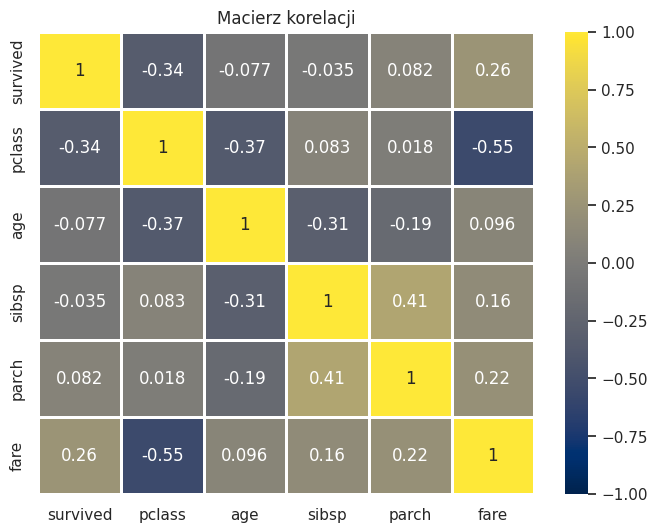

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Wybór kolumn numerycznych (float i int) z DataFrame
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Obliczenie macierzy korelacji pomiędzy zmiennymi numerycznymi
corr_matrix = numeric_df.corr()

# Ustawienie rozmiaru wykresu dla lepszej czytelności
plt.figure(figsize=(8, 6))

# Wizualizacja macierzy korelacji w formie mapy cieplnej
# annot=True – wyświetlanie wartości liczbowych na wykresie
# vmin i vmax – zakres wartości korelacji
# linewidths – odstępy między komórkami
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='cividis',
    vmin=-1,
    vmax=1,
    linewidths=1
)

# Dodanie tytułu wykresu
plt.title('Macierz korelacji')

# Wyświetlenie wizualizacji
plt.show()

Dyskusja wyników

1. Co się dzieje, gdy dwie zmienne są silnie skorelowane?
Silna korelacja pomiędzy dwiema zmiennymi oznacza, że niosą one bardzo podobną informację. W praktyce jedna z nich może być częściowo redundantna, ponieważ jej wartości można w dużym stopniu przewidzieć na podstawie drugiej zmiennej. Może to prowadzić do nadmiarowości informacji w modelu.

2. Czy podwójnie „liczymy” tę samą informację w odległości?
Tak. W przypadku silnie skorelowanych zmiennych ich wspólny wkład do miary odległości (np. euklidesowej) może być zawyżony. W efekcie te same informacje mają większy wpływ na wynik, co prowadzi do zniekształcenia rzeczywistej odległości pomiędzy obserwacjami.

W związku z tym często zaleca się redukcję wymiarowości (np. PCA) lub eliminację silnie skorelowanych cech przed zastosowaniem metod opartych na odległości.

### **Zad 5.** Rozkład klas

In [25]:
# Wyświetlenie wszystkich nazw kolumn
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


In [26]:
# Rozkład zmiennej docelowej (target), czyli kolumny 'survived'
target_distribution = df['survived'].value_counts(normalize=True)

print("Rozkład wartości w kolumnie 'survived':")
print(target_distribution)

Rozkład wartości w kolumnie 'survived':
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [27]:
# Analiza rozkładu zmiennej 'alive' (czy osoba przeżyła)
# normalize=True zwraca proporcje zamiast liczności

alive_distribution = df['alive'].value_counts(normalize=True)

# Wyświetlenie wyników
print("Rozkład wartości w kolumnie 'alive':")
print(alive_distribution)


Rozkład wartości w kolumnie 'alive':
alive
no     0.616162
yes    0.383838
Name: proportion, dtype: float64


Dyskusja wyników

1. Co oznacza, że klasy są niezbalansowane?
Niezbalansowanie klas występuje w sytuacji, gdy jedna z klas w zbiorze danych znacząco dominuje nad pozostałymi. Oznacza to, że rozkład klas jest nierównomierny, np. 90% obserwacji należy do jednej klasy, a pozostałe 10% do drugiej.

2. Jak nierównomierny rozkład klas wpływa na uczenie modelu?
Modele uczące się na danych niezbalansowanych mają tendencję do faworyzowania klasy dominującej, ponieważ minimalizacja funkcji błędu często prowadzi do lepszego dopasowania do większości danych. W rezultacie model może gorzej identyfikować lub wręcz ignorować klasę mniejszościową.

3. Jakie są konsekwencje dominacji jednej klasy?
Pomimo wysokiej ogólnej dokładności (accuracy), model może wykazywać niską skuteczność w wykrywaniu klasy mniejszościowej. W praktyce prowadzi to do mylącej oceny jakości modelu, dlatego w takich przypadkach stosuje się dodatkowe metryki, takie jak precision, recall, F1-score, oraz techniki balansowania danych (np. oversampling, undersampling, SMOTE).

### Wnioski końcowe

Dyskusja wyników

1. Czy metryka euklidesowa jest wrażliwa na różne skale atrybutów?
Tak, metryka euklidesowa jest bardzo wrażliwa na różnice w skali zmiennych. Cechy o większych wartościach liczbowych mają większy wpływ na wynik odległości, co może prowadzić do ich dominacji nad pozostałymi zmiennymi. Na podstawie wcześniejszych analiz (np. różnic takich jak [100, -1]) można zauważyć, że składniki o większej skali wnoszą większy wkład do końcowej odległości. Z tego powodu konieczne jest stosowanie standaryzacji lub normalizacji danych przed obliczaniem odległości.

2. Czy korelacja cech wpływa na metody oparte na odległości?
Tak. Silnie skorelowane cechy wprowadzają redundantną informację, co oznacza, że ta sama informacja jest uwzględniana wielokrotnie w obliczeniach odległości. Może to prowadzić do jej zniekształcenia oraz zmniejszenia wiarygodności wyników, co zostało zaobserwowane przy analizie macierzy korelacji.

3. Jak wzrost liczby cech wpływa na odległości?
Wraz ze wzrostem liczby wymiarów obserwacje stają się coraz bardziej do siebie podobne pod względem odległości. Zjawisko to, znane jako „curse of dimensionality”, powoduje trudności w rozróżnianiu punktów danych oraz pogarsza skuteczność metod opartych na odległościach.

4. Które statystyki opisowe oceniają informacyjność cech?
Do oceny informacyjności zmiennych można wykorzystać następujące miary:

odchylenie standardowe (std) – określa poziom zmienności; niska wartość może wskazywać na niewielką informacyjność,
korelacja – pozwala wykryć redundancję i zależności między cechami,
rozkład wartości (value_counts) – umożliwia ocenę balansu oraz struktury danych.

Miary te wspierają proces selekcji istotnych cech w modelu.

5. Czy ten zbiór danych nadaje się do uczenia modelu?
Zbiór danych może być wykorzystany do uczenia modeli, jednak wymaga odpowiedniego przygotowania, w tym:

obsługi brakujących wartości (usunięcie lub imputacja),
standaryzacji lub normalizacji cech,
analizy korelacji i ewentualnego usunięcia zmiennych redundantnych,
oceny balansu klas (np. w zmiennej survived).

Dopiero po wykonaniu tych kroków dane będą odpowiednio przygotowane do budowy i trenowania modeli uczenia maszynowego.